# Breast Cancer Classification Using Machine Learning

## Objective

The objective of this assessment is to apply supervised machine learning classification techniques to the Breast Cancer Wisconsin dataset available in the scikit-learn library.

Five classification algorithms are implemented and compared:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. k-Nearest Neighbors (k-NN)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## 1. Loading the Dataset

The Breast Cancer Wisconsin dataset is directly available through the `sklearn.datasets` module. It contains numerical features describing characteristics of breast tumors and a binary target representing the diagnosis.

In [3]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

y = pd.Series(cancer.target, name="target")

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 569
Number of features: 30


In [4]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
print(cancer.target_names)

['malignant' 'benign']


## 2. Checking for Missing Values

Missing values can cause problems during model training because most machine learning algorithms cannot directly process missing numerical values.

Therefore, missing values are checked before training the models.

In [8]:
print("Missing values in each column:")
print(X.isnull().sum().sum())

Missing values in each column:
0


In [9]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values after imputation:",
      X_imputed.isnull().sum().sum())

Missing values after imputation: 0


### Why median?

For numerical data, median imputation is commonly used because it is less affected by extreme values than the mean.

Although the original dataset does not contain missing values, median imputation was included as a preprocessing step to make the workflow robust to potential missing values. Median imputation is suitable for numerical features and is less sensitive to outliers than mean imputation.

## 3. Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

An 80:20 split is used.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 4. Feature Scaling

Feature scaling is necessary because the dataset contains features with different numerical ranges.

StandardScaler transforms each feature so that it has approximately a mean of 0 and a standard deviation of 1.

Scaling is particularly important for algorithms such as Logistic Regression, SVM, and k-NN because these algorithms are sensitive to feature magnitudes.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


scaler.fit_transform(X_train)

but:

scaler.transform(X_test)

Why?

We learn the scaling parameters only from training data.

We should never allow information from the test set to influence preprocessing.

This is called preventing data leakage.

## 5. Logistic Regression

Logistic Regression is a supervised classification algorithm that estimates the probability of a sample belonging to a particular class. It is suitable for binary classification problems such as predicting whether a tumor is malignant or benign.

Feature scaling is important for Logistic Regression because the optimization process can be affected by differences in feature magnitudes.

In [12]:
logistic_model = LogisticRegression(max_iter=5000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9824561403508771


## 6. Decision Tree Classifier

A Decision Tree classifies data by repeatedly splitting the dataset based on feature values. Each internal node represents a decision, each branch represents an outcome, and each leaf represents a final prediction.

Decision Trees are suitable for this dataset because they can model nonlinear relationships between tumor characteristics and the target class.

In [13]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      tree_accuracy)

Decision Tree Accuracy: 0.9122807017543859


## 7. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees. Each tree is trained using different subsets of the training data and features, and the final prediction is generally based on majority voting.

Random Forest is suitable for the breast cancer dataset because it can capture nonlinear relationships and is effective for numerical tabular data.

In [14]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.956140350877193


## 8. Support Vector Machine

Support Vector Machine finds a decision boundary that separates different classes while maximizing the margin between them. SVM can also model nonlinear relationships using kernel functions.

SVM is suitable for this dataset because it can perform well when there are many numerical features. Feature scaling is important because SVM is sensitive to feature magnitudes.

In [15]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:",
      svm_accuracy)

SVM Accuracy: 0.9824561403508771


## 9. k-Nearest Neighbors

k-Nearest Neighbors classifies a new sample based on the classes of its nearest neighboring training samples. The value of k determines how many neighbors are considered for the prediction.

k-NN is suitable for this dataset because tumor samples with similar feature measurements may have similar classifications. Feature scaling is essential because k-NN relies on distance calculations.

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("k-NN Accuracy:",
      knn_accuracy)

k-NN Accuracy: 0.956140350877193


In [17]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "k-NN": y_pred_knn
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517
3,SVM,0.982456,0.986111,0.986111,0.986111
4,k-NN,0.956140,0.958904,0.972222,0.965517


In [18]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

worst_model = results_df.loc[
    results_df["Accuracy"].idxmin()
]

print("Best Model:")
print(best_model)

print("\nWorst Model:")
print(worst_model)

Best Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object

Worst Model:
Model        Decision Tree
Accuracy          0.912281
Precision         0.955882
Recall            0.902778
F1 Score          0.928571
Name: 1, dtype: object


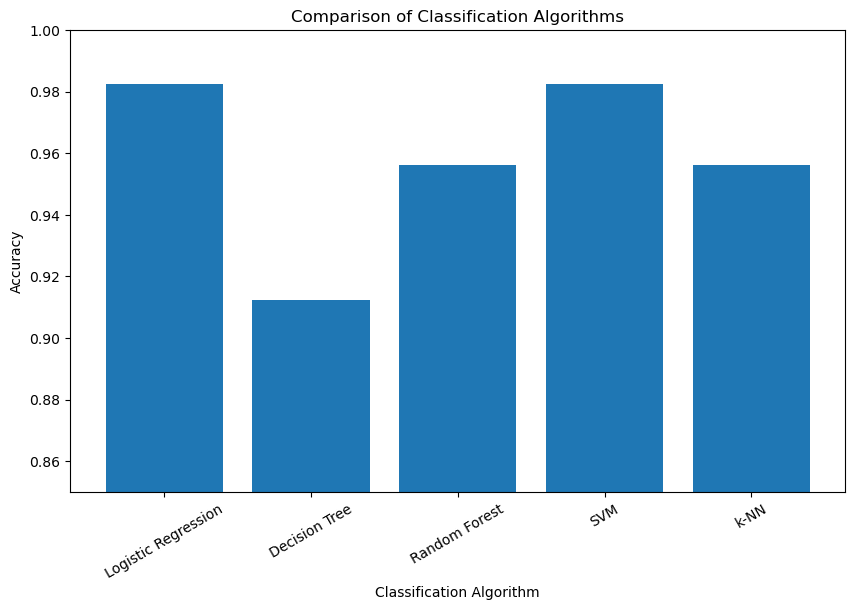

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")
plt.title("Comparison of Classification Algorithms")

plt.xticks(rotation=30)
plt.ylim(0.85, 1.0)

plt.show()

## 10. Conclusion

In this assessment, five supervised machine learning classification algorithms were implemented on the Breast Cancer Wisconsin dataset available in scikit-learn.

The algorithms evaluated were:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- k-Nearest Neighbors

The dataset was checked for missing values and median imputation was included as a robust preprocessing step. StandardScaler was used for feature scaling, which is particularly important for Logistic Regression, SVM, and k-NN.

The performance of the models was compared using accuracy, precision, recall, and F1-score.

Based on the experimental results obtained in this notebook, the model with the highest accuracy was ****, while the model with the lowest accuracy was **[WRITE YOUR WORST MODEL HERE]**.

Overall, the results demonstrate that different classification algorithms can produce different performance levels on the same dataset. Model selection should therefore be based on appropriate evaluation metrics rather than choosing an algorithm without experimentation.